Found 5494 files belonging to 12 classes.
Using 4396 files for training.
Found 5494 files belonging to 12 classes.
Using 1098 files for validation.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 44s 286ms/step - accuracy: 0.6656 - loss: 1.2903 - val_accuracy: 0.8962 - val_loss: 0.4167
Epoch 2/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 292ms/step - accuracy: 0.8934 - loss: 0.3820 - val_accuracy: 0.9080 - val_loss: 0.3349
Epoch 3/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 40s 287ms/step - accuracy: 0.9243 - loss: 0.2777 - val_accuracy: 0.9144 - val_loss: 0.3015
Epoch 4/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 284ms/step - accuracy: 0.9323 - loss: 0.2397 - val_accuracy: 0.9199 - val_loss: 0.2870
Epoch 5/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 39s 280ms/step - accuracy: 0.9455 - loss: 0.2014 - val_accuracy: 0.9180 - val_loss: 0.2781


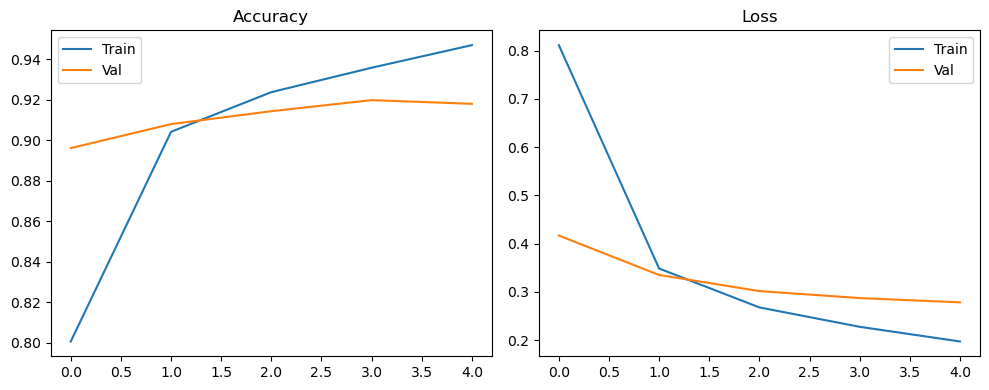

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Config
dataset_dir = r"D:\Ed\DL\Proj\pest" # CHANGE THIS
img_size = (224, 224)
batch_size = 32
epochs = 5

# Load data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Preprocess
preprocess_input = tf.keras.applications.efficientnet.preprocess_input

# Model
base_model = EfficientNetB0(input_shape=img_size + (3,), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

model.save("efficientnetb0_pest_classifier.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("efficientnetb0_training_plot.png")
plt.show()
